# SOB4ES - Extractor automatico de resultados entre ramas

Este notebook automatiza lo que se ha estado haciendo a mano hasta ahora: leer los notebooks de una rama de git (sin necesidad de hacer `checkout`, usando `git show rama:archivo`), extraer las metricas de evaluacion, el numero de variables activas, y detectar automaticamente dos problemas que ya han aparecido varias veces de forma manual:

1. **Variables que no coinciden** entre lo que dice `FEATURES_AUTORIZADAS` y lo que realmente se cargo en `X_train` (columna comentada pero no re-ejecutado).
2. **Celdas ejecutadas fuera de orden** (`execution_count` no creciente de arriba a abajo), que es la causa raiz de los resultados "pegados" de una ejecucion anterior (el bug que se detecto en `regressorchain.ipynb` y `mlp_custom_loss.ipynb`).

Compara dos ramas cualesquiera (p. ej. `main` contra `prueba1-iteracion-2`) para los 8 notebooks de modelos, y genera la misma tabla comparativa que se ha ido pidiendo manualmente en el chat.

**Requisito:** tener el repositorio clonado localmente (funciona sobre tu copia local de git, sin necesidad de subir nada a ningun sitio). No hace falta hacer `git checkout` de las ramas - se leen los archivos directamente del historial de git.


## 0.- Configuración

In [17]:
import os
import json
import re
import pandas as pd
from io import StringIO
from IPython.display import display
import subprocess

# --- EDITA ESTO ---
GIT_REPO_PATH = "."  # Usar '.' si ejecutas el notebook dentro del repositorio

# Modifica para definir las ramas a comparar
BRANCHES = [
    "model-prep-var",
    # "model-prep-var-x-y",   Añade más ramas según necesites
]

BRANCHES_BARRIDO = [
    "model-prep-rs-group",   # AJUSTA: nombres reales de las 2 ramas
    "model-prep-rs-group-1",
]

# Notebooks a analizar
NOTEBOOKS = [
    "reg_model.ipynb",
    "rf_model.ipynb",
    "rf_multisalida.ipynb",
    "regressorchain.ipynb",
    "xgboost_model.ipynb",
    "xgb_multisalida.ipynb",
    "mlp_multisalida.ipynb",
    "mlp_custom_loss.ipynb",
]

NOTEBOOKS_SUBDIR = ""

# Lista completa de targets a extraer y comparar
TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z',
]

# Define los targets prioritarios que quieres destacar en la tabla comparativa
TARGETS_PRIORITARIOS = ["earthworm_shannon_z", "earthworm_richness_z"]

## 1.- Funciones de lectura desde git

`obtener_notebook_desde_git` usa `git show <rama>:<archivo>` para leer el contenido de un archivo tal y como esta en una rama concreta, sin tocar el working directory ni hacer checkout. Si el repo es remoto y no lo tienes clonado, hay una alternativa comentada al final de la celda usando la API de GitHub (`raw.githubusercontent.com`).

In [18]:
def obtener_notebook_desde_git(repo_path, branch, filename, subdir=""):
    """Lee un .ipynb tal y como está en una rama concreta, vía `git show`, sin checkout."""
    ruta_relativa = os.path.join(subdir, filename) if subdir else filename
    try:
        resultado = subprocess.run(
            ["git", "-C", repo_path, "show", f"{branch}:{ruta_relativa}"],
            capture_output=True,
            text=True,
            check=True,
        )
    except subprocess.CalledProcessError as e:
        print(
            f"  [ERROR] No se pudo leer {filename} en la rama {branch}: {e.stderr.strip()}"
        )
        return None
    return json.loads(resultado.stdout)


def listar_ramas(repo_path):
    """Útil para comprobar el nombre exacto de las ramas disponibles (locales y remotas)."""
    resultado = subprocess.run(
        ["git", "-C", repo_path, "branch", "-a"],
        capture_output=True,
        text=True,
    )
    print(resultado.stdout)

## 2.- Funciones de extracción

- `extraer_features_activas`: parsea la lista `FEATURES_AUTORIZADAS` y separa las lineas comentadas (excluidas) de las activas.
- `extraer_shape_xtrain`: busca el print de `X_train: (filas, columnas)` para saber cuantas variables se usaron realmente en el entrenamiento.
- `detectar_celdas_desordenadas`: compara el `execution_count` de las celdas de codigo en el orden en que aparecen en el notebook; si no es creciente, señala un posible problema de ejecucion (resultados de una corrida anterior, no de la actual).
- `extraer_metricas_targets`: busca en los outputs de texto, **a partir del marcador "Evaluacion final sobre eval.csv"**, las lineas con R2/RMSE/MAE para los targets pedidos. Restringir la busqueda a ese bloque es importante: sin eso, el regex puede confundirse con el R2 de entrenamiento/CV impreso en las celdas de tuning (mucho mas alto por sobreajuste) y dar una lectura falsa. Soporta dos formatos: modelos single-target (R2+RMSE+MAE por target) y modelos multisalida (solo R2 por target, con RMSE/MAE unicamente a nivel global).

In [19]:
def extraer_features_activas(nb_json):
    for c in nb_json["cells"]:
        src = "".join(c.get("source", []))
        if "FEATURES_AUTORIZADAS =" in src:
            m = re.search(r"FEATURES_AUTORIZADAS\s*=\s*\[(.*?)\]", src, re.S)
            if not m:
                continue
            lineas = [l.strip() for l in m.group(1).split("\n") if l.strip()]
            activas, excluidas = [], []
            for linea in lineas:
                nombre_m = re.search(r"'([^']+)'", linea)
                if not nombre_m:
                    continue
                nombre = nombre_m.group(1)
                if linea.startswith("#"):
                    excluidas.append(nombre)
                else:
                    activas.append(nombre)
            return activas, excluidas
    return [], []


def extraer_shape_xtrain(nb_json):
    for c in nb_json["cells"]:
        for out in c.get("outputs", []):
            texto = "".join(out.get("text", []))
            m = re.search(r"X_train:\s*\((\d+),\s*(\d+)\)", texto)
            if m:
                return int(m.group(1)), int(m.group(2))
    return None, None


def detectar_celdas_desordenadas(nb_json):
    """Devuelve una lista de avisos si el execution_count no es creciente."""
    avisos = []
    ultimo_exec = None
    for i, c in enumerate(nb_json["cells"]):
        if c.get("cell_type") != "code":
            continue
        exec_count = c.get("execution_count")
        if exec_count is None:
            continue
        if ultimo_exec is not None and exec_count < ultimo_exec:
            avisos.append(
                f"celda #{i} tiene execution_count={exec_count}, "
                f"menor que una celda anterior ({ultimo_exec}) -> posible resultado obsoleto"
            )
        ultimo_exec = exec_count
    return avisos


MARCADOR_EVAL = "Evaluacion final sobre eval.csv"


def extraer_metricas_targets(nb_json, targets):
    """Extrae R2/RMSE/MAE de la evaluación final para cada target."""
    resultados = {}
    patron_completo = {
        t: re.compile(
            rf"{re.escape(t)}\s+([\-0-9.]+)\s+([\-0-9.]+)\s+([\-0-9.]+)"
        )
        for t in targets
    }
    patron_solo_r2 = {
        t: re.compile(rf"{re.escape(t)}\s+([\-0-9.]+)\s*$", re.M)
        for t in targets
    }
    patron_global = re.compile(
        r"R2\s+global:\s*([\-0-9.]+).*?RMSE\s+global:\s*([\-0-9.]+).*?MAE\s+global:\s*([\-0-9.]+)",
        re.S,
    )

    for c in nb_json["cells"]:
        # OJO: algunos notebooks (rf_multisalida, xgb_multisalida, regressorchain)
        # imprimen la cabecera "Evaluacion final..." y el bloque de métricas en
        # dos print() distintos, que Jupyter guarda como dos outputs SEPARADOS
        # dentro de la misma celda. Por eso hay que concatenar todos los outputs
        # de la celda ANTES de buscar el marcador, en vez de mirarlos uno a uno.
        texto_completo = "".join(
            "".join(out.get("text", []))
            for out in c.get("outputs", [])
            if out.get("output_type") == "stream"
        )
        if MARCADOR_EVAL not in texto_completo:
            continue
        texto = texto_completo[texto_completo.index(MARCADOR_EVAL):]

        g = patron_global.search(texto)
        global_metrics = (
            {
                "r2_global": float(g.group(1)),
                "rmse_global": float(g.group(2)),
                "mae_global": float(g.group(3)),
            }
            if g
            else None
        )

        for t in targets:
            if t in resultados:
                continue
            m = patron_completo[t].search(texto)
            if m:
                resultados[t] = {
                    "r2": float(m.group(1)),
                    "rmse": float(m.group(2)),
                    "mae": float(m.group(3)),
                }
                continue
            m2 = patron_solo_r2[t].search(texto)
            if m2:
                resultados[t] = {
                    "r2": float(m2.group(1)),
                    "rmse": None,
                    "mae": None,
                    "global": global_metrics,
                }
    return resultados


def extraer_random_state(nb_json):
    """Busca el random_state usado para entrenar. Prioriza una constante de
    configuración tipo `RANDOM_STATE = N`; si no existe, coge la primera
    aparición de `random_state=N` que encuentre en el código."""
    codigo_completo = "\n".join(
        "".join(c.get("source", []))
        for c in nb_json["cells"]
        if c.get("cell_type") == "code"
    )
    m = re.search(r"RANDOM_STATE\s*=\s*(\d+)", codigo_completo)
    if m:
        return int(m.group(1))
    m2 = re.search(r"random_state\s*=\s*(\d+)", codigo_completo)
    if m2:
        return int(m2.group(1))
    return None

In [20]:
def extraer_ruta_csv_barrido(nb_json):
    """Deduce la ruta del CSV de resultados del barrido de random_state
    leyendo el propio código del notebook (MODELS_DIR + dir_barrido +
    el nombre de archivo del .to_csv), en vez de asumir un nombre fijo tipo
    'ridge_barrido_rs.csv' -- así sirve igual para RF, XGBoost, etc."""
    codigo = "\n".join(
        "".join(c.get("source", []))
        for c in nb_json["cells"]
        if c.get("cell_type") == "code"
    )

    m_dir = re.search(r"MODELS_DIR\s*=\s*['\"]([^'\"]+)['\"]", codigo)
    models_dir = m_dir.group(1) if m_dir else ""

    m_sub = re.search(
        r"dir_barrido\s*=\s*os\.path\.join\(\s*MODELS_DIR\s*,\s*['\"]([^'\"]+)['\"]\s*\)", codigo
    )
    if not m_sub:
        return None
    subdir = m_sub.group(1)

    m_file = re.search(
        r"\.to_csv\(\s*os\.path\.join\(\s*dir_barrido\s*,\s*['\"]([^'\"]+)['\"]\s*\)", codigo
    )
    if not m_file:
        return None
    filename = m_file.group(1)

    return "/".join(p.strip("/") for p in [models_dir, subdir, filename] if p)


def obtener_csv_desde_git(repo_path, branch, ruta_csv):
    """Lee un CSV vía `git show`, igual que obtener_notebook_desde_git pero
    parseando CSV en vez de JSON."""
    try:
        resultado = subprocess.run(
            ["git", "-C", repo_path, "show", f"{branch}:{ruta_csv}"],
            capture_output=True, text=True, check=True,
        )
    except subprocess.CalledProcessError as e:
        print(f"  [ERROR] No se pudo leer {ruta_csv} en la rama {branch}: {e.stderr.strip()}")
        return None
    return pd.read_csv(StringIO(resultado.stdout))


def extraer_rango_esperado_rs(nb_json):
    """Lee `RANDOM_STATES = range(a, b)` o `range(a, b, paso)` del código y
    devuelve cuántas semillas se esperan, para poder comparar contra las
    filas que realmente tiene el CSV del barrido."""
    codigo = "\n".join(
        "".join(c.get("source", []))
        for c in nb_json["cells"]
        if c.get("cell_type") == "code"
    )
    m = re.search(
        r"RANDOM_STATES\s*=\s*range\(\s*(\d+)\s*,\s*(\d+)\s*(?:,\s*(\d+)\s*)?\)", codigo
    )
    if not m:
        return None
    inicio, fin = int(m.group(1)), int(m.group(2))
    paso = int(m.group(3)) if m.group(3) else 1
    return len(range(inicio, fin, paso))

## 3.- Extracción de notebooks y por rama

In [21]:
def analizar_notebook(repo_path, branch, filename, subdir, targets):
    nb_json = obtener_notebook_desde_git(repo_path, branch, filename, subdir)
    if nb_json is None:
        return None

    activas, excluidas = extraer_features_activas(nb_json)
    filas, columnas = extraer_shape_xtrain(nb_json)
    metricas = extraer_metricas_targets(nb_json, targets)
    avisos_orden = detectar_celdas_desordenadas(nb_json)
    random_state = extraer_random_state(nb_json)

    return {
        "n_features_lista": len(activas),
        "features_excluidas": excluidas,
        "x_train_shape": (filas, columnas),
        "coherente": (
            (columnas == len(activas)) if columnas is not None else None
        ),
        "metricas": metricas,
        "avisos_orden": avisos_orden,
        "random_state": random_state,
    }


resultados_por_rama = {}

for branch in BRANCHES:
    print(f"Leyendo notebooks de la rama: {branch}...")
    resultados_por_rama[branch] = {}
    for nb_name in NOTEBOOKS:
        print(f"  {nb_name}")
        resultados_por_rama[branch][nb_name] = analizar_notebook(
            GIT_REPO_PATH,
            branch,
            nb_name,
            NOTEBOOKS_SUBDIR,
            TARGETS,
        )
    print()

Leyendo notebooks de la rama: model-prep-var...
  reg_model.ipynb
  rf_model.ipynb
  rf_multisalida.ipynb
  regressorchain.ipynb
  xgboost_model.ipynb
  xgb_multisalida.ipynb
  mlp_multisalida.ipynb
  mlp_custom_loss.ipynb



## 4. Validaciones automaticas

Antes de comparar metricas, se comprueba automaticamente lo que hasta ahora se ha ido revisando a mano:
- ¿El numero de columnas de `X_train` coincide con el numero de variables activas en `FEATURES_AUTORIZADAS`?
- ¿Hay celdas con `execution_count` fuera de orden (posible resultado obsoleto)?
- ¿Los valores de los targets prioritarios son sospechosamente identicos entre ambas ramas (posible notebook no re-ejecutado)?

In [22]:
print("=" * 100)
print("VALIDACIONES AUTOMÁTICAS")
print("=" * 100)

base_branch = BRANCHES[0]

for nb_name in NOTEBOOKS:
    print(f"\n[{nb_name}]")

    rs_por_notebook = {}
    for branch in BRANCHES:
        r = resultados_por_rama.get(branch, {}).get(nb_name)
        if r is None:
            print(f"  [ERROR - {branch}] No se pudo leer el notebook.")
            continue

        filas, columnas = r["x_train_shape"]
        rs_por_notebook[branch] = r.get("random_state")

        # con estas pruebas NO se eliminan variables: cualquier diferencia
        # en el número de columnas es sospechosa
        if r["coherente"] is False:
            print(
                f"  [AVISO - {branch}] Se esperaban las mismas variables que en el resto "
                f"de ramas (esta prueba no elimina variables), pero X_train tiene {columnas} "
                f"columnas y FEATURES_AUTORIZADAS tiene {r['n_features_lista']} activas -> revisar"
            )
        if r["avisos_orden"]:
            print(f"  [AVISO - {branch}] Celdas ejecutadas fuera de orden:")
            for a in r["avisos_orden"]:
                print(f"      - {a}")

        m = re.search(r"(\d+)\s*$", branch)
        if m and r.get("random_state") is not None:
            rs_esperado = int(m.group(1))
            if r["random_state"] != rs_esperado:
                print(
                    f"  [AVISO - {branch}] El nombre de la rama sugiere random_state={rs_esperado}, "
                    f"pero el notebook usa random_state={r['random_state']}"
                )

    valores_rs = set(v for v in rs_por_notebook.values() if v is not None)
    if len(valores_rs) > 1:
        print(f"  [AVISO] Los notebooks de esta rama no usan todos el mismo random_state: {rs_por_notebook}")

    r_base = resultados_por_rama.get(base_branch, {}).get(nb_name)
    if r_base:
        for comp_branch in BRANCHES[1:]:
            r_comp = resultados_por_rama.get(comp_branch, {}).get(nb_name)
            if not r_comp:
                continue
            for t in TARGETS_PRIORITARIOS:
                m_base = r_base["metricas"].get(t)
                m_comp = r_comp["metricas"].get(t)
                if (
                    m_base
                    and m_comp
                    and m_base.get("r2") == m_comp.get("r2")
                ):
                    print(
                        f"  [AVISO] {t}: R2 IDENTICO en '{base_branch}' y '{comp_branch}' ({m_base['r2']}) "
                        f"-> revisar si se re-ejecutó de verdad"
                    )

VALIDACIONES AUTOMÁTICAS

[reg_model.ipynb]

[rf_model.ipynb]

[rf_multisalida.ipynb]

[regressorchain.ipynb]

[xgboost_model.ipynb]

[xgb_multisalida.ipynb]

[mlp_multisalida.ipynb]

[mlp_custom_loss.ipynb]


## 5- Tablas comparativas

En esta sección se generarán múltiples tablas para facilitar la comparación de resultados.

In [23]:
filas_tabla = []
base_branch = BRANCHES[0]

for nb_name in NOTEBOOKS:
    fila = {"Notebook": nb_name}

    for t in TARGETS_PRIORITARIOS:
        # Obtener R2 de la rama base
        r_base = resultados_por_rama.get(base_branch, {}).get(nb_name)
        m_base = r_base["metricas"].get(t) if r_base else None
        r2_base = m_base["r2"] if m_base else None

        fila[f"{t}_R2 ({base_branch})"] = r2_base

        # R2 y Delta para las ramas a comparar
        for branch in BRANCHES[1:]:
            r_branch = resultados_por_rama.get(branch, {}).get(nb_name)
            m_branch = r_branch["metricas"].get(t) if r_branch else None
            r2_val = m_branch["r2"] if m_branch else None

            fila[f"{t}_R2 ({branch})"] = r2_val

            delta = (
                round(r2_val - r2_base, 4)
                if (r2_val is not None and r2_base is not None)
                else None
            )
            fila[f"{t}_delta ({branch})"] = delta

    filas_tabla.append(fila)

df_comparativa = pd.DataFrame(filas_tabla)

print(f"Comparación entre {len(BRANCHES)} ramas (Base: {base_branch}):\n")
print(df_comparativa.to_string(index=False))

# Guardar resultado en CSV
os.makedirs("output/comparativas", exist_ok=True)
nombre_salida = f"comparativa_{'_vs_'.join(BRANCHES)}.csv".replace("/", "-")
ruta_csv = f"output/comparativas/{nombre_salida}"
df_comparativa.to_csv(ruta_csv, index=False)
print(f"\nGuardado en: {ruta_csv}")

Comparación entre 1 ramas (Base: model-prep-var):

             Notebook  earthworm_shannon_z_R2 (model-prep-var)  earthworm_richness_z_R2 (model-prep-var)
      reg_model.ipynb                                   0.2395                                    0.2789
       rf_model.ipynb                                   0.5041                                    0.5722
 rf_multisalida.ipynb                                   0.4160                                    0.4509
 regressorchain.ipynb                                   0.4876                                    0.5359
  xgboost_model.ipynb                                   0.4946                                    0.5171
xgb_multisalida.ipynb                                   0.5375                                    0.5893
mlp_multisalida.ipynb                                   0.3583                                    0.4539
mlp_custom_loss.ipynb                                   0.3438                                    0.4543

Gua

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

def construir_df_largo_barrido():
    filas = []
    for branch in BRANCHES:
        for nb_name in NOTEBOOKS:
            res = resultados_por_rama.get(branch, {}).get(nb_name)
            if not res:
                continue
            rs = res.get("random_state")
            m_dict = res.get("metricas", {})

            # R2 global (mismo criterio que en la tabla general de la sección 5.1)
            r2_glob = None
            for t_info in m_dict.values():
                if t_info and t_info.get("global"):
                    r2_glob = t_info["global"].get("r2_global")
                    break
            if r2_glob is None and m_dict:
                r2_vals = [v["r2"] for v in m_dict.values() if v and v.get("r2") is not None]
                if r2_vals:
                    r2_glob = sum(r2_vals) / len(r2_vals)
            if r2_glob is not None:
                filas.append({"Notebook": nb_name, "branch": branch, "random_state": rs, "target": "GLOBAL", "r2": r2_glob})

            for t in TARGETS_PRIORITARIOS:
                info = m_dict.get(t)
                if info and info.get("r2") is not None:
                    filas.append({"Notebook": nb_name, "branch": branch, "random_state": rs, "target": t, "r2": info["r2"]})

    return pd.DataFrame(filas)

df_barrido = construir_df_largo_barrido()
print(f"Filas recogidas: {len(df_barrido)} (esperado: hasta {len(BRANCHES)} semillas x {len(NOTEBOOKS)} notebooks x 3 targets)")
df_barrido.head()

Filas recogidas: 24 (esperado: hasta 1 semillas x 8 notebooks x 3 targets)


,Notebook,branch,random_state,target,r2
0,reg_model.ipynb,model-prep-var,42,GLOBAL,-0.016376
1,reg_model.ipynb,model-prep-var,42,earthworm_shannon_z,0.239500
2,reg_model.ipynb,model-prep-var,42,earthworm_richness_z,0.278900
3,rf_model.ipynb,model-prep-var,42,GLOBAL,0.090362
4,rf_model.ipynb,model-prep-var,42,earthworm_shannon_z,0.504100


### 5.1.- Tabla de compraración general

In [25]:
filas_general = []
base_branch = BRANCHES[0]

for nb_name in NOTEBOOKS:
    fila = {"Notebook": nb_name}

    for branch in BRANCHES:
        res = resultados_por_rama.get(branch, {}).get(nb_name)

        if res:
            # Dimensiones de X_train
            shape_str = (
                f"{res['x_train_shape'][0]}x{res['x_train_shape'][1]}"
                if res["x_train_shape"][0]
                else "N/A"
            )
            fila[f"N_Vars ({branch})"] = res["n_features_lista"]
            fila[f"Shape ({branch})"] = shape_str

            # Extracción de métricas globales
            m_dict = res.get("metricas", {})
            r2_glob, rmse_glob, mae_glob = None, None, None

            # 1. Intentar obtener 'global' si el notebook es multisalida
            for t_info in m_dict.values():
                if t_info and t_info.get("global"):
                    r2_glob = t_info["global"].get("r2_global")
                    rmse_glob = t_info["global"].get("rmse_global")
                    mae_glob = t_info["global"].get("mae_global")
                    break

            # 2. Si es single-target, promediar el R2 de los targets evaluados
            if r2_glob is None and m_dict:
                r2_vals = [
                    v["r2"]
                    for v in m_dict.values()
                    if v and v.get("r2") is not None
                ]
                if r2_vals:
                    r2_glob = round(sum(r2_vals) / len(r2_vals), 4)

            fila[f"R2_Global ({branch})"] = r2_glob
            if rmse_glob is not None:
                fila[f"RMSE_Global ({branch})"] = rmse_glob
            if mae_glob is not None:
                fila[f"MAE_Global ({branch})"] = mae_glob

            # Calcular Delta R2 Global respecto al baseline
            if branch != base_branch:
                r2_base = fila.get(f"R2_Global ({base_branch})")
                fila[f"Delta_R2_Global ({branch})"] = (
                    round(r2_glob - r2_base, 4)
                    if (r2_glob is not None and r2_base is not None)
                    else None
                )
        else:
            fila[f"N_Vars ({branch})"] = "Error"
            fila[f"R2_Global ({branch})"] = None

    filas_general.append(fila)

df_general = pd.DataFrame(filas_general)

print("=" * 100)
print(f"1. TABLA COMPARATIVA GENERAL (Base: {base_branch})")
print("=" * 100)
print(df_general.to_markdown(index=False))

# Guardar CSV
os.makedirs("output/comparativas", exist_ok=True)
ruta_csv_gen = f"output/comparativas/general_{'_vs_'.join(BRANCHES)}.csv"
df_general.to_csv(ruta_csv_gen, index=False)
print(f"\nGuardado en: {ruta_csv_gen}")

1. TABLA COMPARATIVA GENERAL (Base: model-prep-var)
| Notebook              |   N_Vars (model-prep-var) | Shape (model-prep-var)   |   R2_Global (model-prep-var) |   RMSE_Global (model-prep-var) |   MAE_Global (model-prep-var) |
|:----------------------|--------------------------:|:-------------------------|-----------------------------:|-------------------------------:|------------------------------:|
| reg_model.ipynb       |                        34 | 299x34                   |                      -0.0164 |                       nan      |                      nan      |
| rf_model.ipynb        |                        34 | 299x34                   |                       0.0904 |                       nan      |                      nan      |
| rf_multisalida.ipynb  |                        34 | 299x34                   |                       0.0964 |                         0.9198 |                        0.7026 |
| regressorchain.ipynb  |                        34 | 299x34   

### 5.2.- Comparación por targets

In [26]:
from collections import Counter
from IPython.display import display, HTML

base_branch = BRANCHES[0]
tablas_por_target = {}
html_partes = []

def obtener_label_rama(branch):
    """Etiqueta la rama con el random_state usado, tomando el valor más
    frecuente entre los 8 notebooks (por si alguno estuviera desincronizado)."""
    conteos = Counter()
    for nb_name in NOTEBOOKS:
        res = resultados_por_rama.get(branch, {}).get(nb_name)
        if res and res.get("random_state") is not None:
            conteos[res["random_state"]] += 1
    if not conteos:
        return branch
    rs_comun = conteos.most_common(1)[0][0]
    return f"rs={rs_comun}"

LABELS_RAMA = {branch: obtener_label_rama(branch) for branch in BRANCHES}

os.makedirs("output/comparativas", exist_ok=True)

for target in TARGETS:
    filas_target = []

    for nb_name in NOTEBOOKS:
        fila = {"Notebook": nb_name}

        for branch in BRANCHES:
            res = resultados_por_rama.get(branch, {}).get(nb_name)
            m = (
                res["metricas"].get(target)
                if (res and res.get("metricas"))
                else None
            )
            fila[f"R2 ({LABELS_RAMA[branch]})"] = m["r2"] if m else None

        filas_target.append(fila)

    df_target = pd.DataFrame(filas_target)

    cols_r2 = [c for c in df_target.columns if c != "Notebook"]
    fila_media = {"Notebook": "MEDIA GLOBAL"}
    for col in cols_r2:
        fila_media[col] = df_target[col].mean(skipna=True)
    df_target = pd.concat([df_target, pd.DataFrame([fila_media])], ignore_index=True)

    tablas_por_target[target] = df_target

    html_target = df_target.to_html(
        index=False, na_rep="—", float_format=lambda x: f"{x:.4f}"
    )

    print("=" * 100)
    print(f"2. TABLA COMPARATIVA POR TARGET: {target} (Base: {LABELS_RAMA[base_branch]})")
    print("=" * 100)
    display(HTML(html_target))

    ruta_html_target = f"output/comparativas/por_target_{target}_{'_vs_'.join(BRANCHES)}.html"
    with open(ruta_html_target, "w", encoding="utf-8") as f:
        f.write(html_target)
    print(f"Guardado en: {ruta_html_target}\n")

    html_partes.append(f"<h2>{target}</h2>\n{html_target}")

html_final = (
    "<html><head><meta charset='utf-8'>"
    "<style>table{border-collapse:collapse;margin-bottom:30px;} "
    "th,td{border:1px solid #ccc;padding:4px 8px;text-align:right;} "
    "th{background:#f0f0f0;} td:first-child,th:first-child{text-align:left;}</style>"
    "</head><body>"
    f"<h1>Comparativa por targets (Base: {LABELS_RAMA[base_branch]})</h1>"
    + "\n".join(html_partes)
    + "</body></html>"
)

ruta_html_final = f"output/comparativas/todas_las_tablas_{'_vs_'.join(BRANCHES)}.html"
with open(ruta_html_final, "w", encoding="utf-8") as f:
    f.write(html_final)

print("=" * 100)
print(f"Export final con todas las tablas guardado en: {ruta_html_final}")
print("=" * 100)

2. TABLA COMPARATIVA POR TARGET: nematode_shannon_z (Base: rs=42)


Notebook,R2 (rs=42)
reg_model.ipynb,0.0112
rf_model.ipynb,0.1693
rf_multisalida.ipynb,0.1545
regressorchain.ipynb,0.1467
xgboost_model.ipynb,0.1637
xgb_multisalida.ipynb,0.2228
mlp_multisalida.ipynb,0.0656
mlp_custom_loss.ipynb,0.0520
MEDIA GLOBAL,0.1232


Guardado en: output/comparativas/por_target_nematode_shannon_z_model-prep-var.html

2. TABLA COMPARATIVA POR TARGET: macro_shannon_z (Base: rs=42)


Notebook,R2 (rs=42)
reg_model.ipynb,0.1257
rf_model.ipynb,0.3199
rf_multisalida.ipynb,0.2000
regressorchain.ipynb,0.2804
xgboost_model.ipynb,0.2601
xgb_multisalida.ipynb,0.3771
mlp_multisalida.ipynb,0.2101
mlp_custom_loss.ipynb,0.1817
MEDIA GLOBAL,0.2444


Guardado en: output/comparativas/por_target_macro_shannon_z_model-prep-var.html

2. TABLA COMPARATIVA POR TARGET: earthworm_shannon_z (Base: rs=42)


...

Guardado en: output/comparativas/por_target_euk_asv_richness_z_model-prep-var.html

2. TABLA COMPARATIVA POR TARGET: oomy_asv_richness_z (Base: rs=42)


Notebook,R2 (rs=42)
reg_model.ipynb,0.1035
rf_model.ipynb,0.1843
rf_multisalida.ipynb,0.1917
regressorchain.ipynb,0.2019
xgboost_model.ipynb,0.1776
xgb_multisalida.ipynb,0.1650
mlp_multisalida.ipynb,0.0911
mlp_custom_loss.ipynb,0.0849
MEDIA GLOBAL,0.1500


Guardado en: output/comparativas/por_target_oomy_asv_richness_z_model-prep-var.html

2. TABLA COMPARATIVA POR TARGET: cerc_asv_richness_z (Base: rs=42)


Notebook,R2 (rs=42)
reg_model.ipynb,0.1019
rf_model.ipynb,0.1250
rf_multisalida.ipynb,0.1171
regressorchain.ipynb,0.1171
xgboost_model.ipynb,0.1227
xgb_multisalida.ipynb,0.0983
mlp_multisalida.ipynb,0.0380
mlp_custom_loss.ipynb,-0.0008
MEDIA GLOBAL,0.0899


Guardado en: output/comparativas/por_target_cerc_asv_richness_z_model-prep-var.html

Export final con todas las tablas guardado en: output/comparativas/todas_las_tablas_model-prep-var.html


## 7. Ranking de modelos

Se calcula directamente a partir de las métricas ya extraídas. Rank 1 = mejor modelo (mayor R²) en esa rama/target.

In [27]:
print("=" * 100)
print("7.1.- RANKING POR RAMA (R2 global, 1 = mejor modelo)")
print("=" * 100)

r2_global_cols = [c for c in df_general.columns if c.startswith("R2_Global (")]
ranking_global = df_general.set_index("Notebook")[r2_global_cols].rank(ascending=False, axis=0)
ranking_global.columns = [c.replace("R2_Global (", "").rstrip(")") for c in ranking_global.columns]

print(ranking_global.to_string())

resumen_ranking = pd.DataFrame({
    "Ranking medio": ranking_global.mean(axis=1).round(2),
    "Desviacion (estabilidad)": ranking_global.std(axis=1).round(2),
}).sort_values("Ranking medio")

print("\n" + "=" * 100)
print("7.2.- RANKING MEDIO Y ESTABILIDAD ENTRE RAMAS")
print("=" * 100)
print(resumen_ranking.to_string())

os.makedirs("output/comparativas", exist_ok=True)
ruta_ranking = f"output/comparativas/ranking_global_{'_vs_'.join(BRANCHES)}.csv"
ranking_global.to_csv(ruta_ranking)
print(f"\nGuardado en: {ruta_ranking}")

7.1.- RANKING POR RAMA (R2 global, 1 = mejor modelo)
                       model-prep-var
Notebook                             
reg_model.ipynb                   7.0
rf_model.ipynb                    2.0
rf_multisalida.ipynb              1.0
regressorchain.ipynb              4.0
xgboost_model.ipynb               5.0
xgb_multisalida.ipynb             3.0
mlp_multisalida.ipynb             6.0
mlp_custom_loss.ipynb             8.0

7.2.- RANKING MEDIO Y ESTABILIDAD ENTRE RAMAS
                       Ranking medio  Desviacion (estabilidad)
Notebook                                                      
rf_multisalida.ipynb             1.0                       NaN
rf_model.ipynb                   2.0                       NaN
xgb_multisalida.ipynb            3.0                       NaN
regressorchain.ipynb             4.0                       NaN
xgboost_model.ipynb              5.0                       NaN
mlp_multisalida.ipynb            6.0                       NaN
reg_model.ipynb 

## 8. Barrido de random_state

Dos ramas, cada una entrena un modelo por semilla dentro de un rango y guarda el resultado en un CSV propio (`MODELS_DIR/barrido_rs_<modelo>/<...>.csv`). Aquí se lee ese CSV directamente vía `git show`, no se parsea el notebook.

In [28]:
barrido_por_rama = {}

for branch in BRANCHES_BARRIDO:
    print(f"Leyendo barridos de la rama: {branch}...")
    barrido_por_rama[branch] = {}
    conteos_rama = {}

    for nb_name in NOTEBOOKS:
        nb_json = obtener_notebook_desde_git(GIT_REPO_PATH, branch, nb_name, NOTEBOOKS_SUBDIR)
        if nb_json is None:
            continue
        ruta_csv = extraer_ruta_csv_barrido(nb_json)
        if ruta_csv is None:
            print(f"  [AVISO] {nb_name}: no se encontró la celda de barrido (¿no tiene Prueba 3 todavía?)")
            continue

        df_csv = obtener_csv_desde_git(GIT_REPO_PATH, branch, ruta_csv)
        if df_csv is None:
            barrido_por_rama[branch][nb_name] = None
            continue

        n_real = len(df_csv)
        n_esperado = extraer_rango_esperado_rs(nb_json)
        conteos_rama[nb_name] = n_real

        etiqueta_check = ""
        if n_esperado is not None and n_real != n_esperado:
            etiqueta_check = f"  [AVISO] se esperaban {n_esperado} semillas (RANDOM_STATES en el código), CSV tiene {n_real}"

        print(f"  {nb_name}: {ruta_csv} -> {n_real} semillas{etiqueta_check}")
        barrido_por_rama[branch][nb_name] = df_csv

    # dentro de la misma rama, todos los notebooks deberían barrer el mismo
    # rango de semillas -- si uno se queda corto respecto al resto, avisar
    if len(set(conteos_rama.values())) > 1:
        print(f"  [AVISO] No todos los notebooks de '{branch}' tienen el mismo número de semillas: {conteos_rama}")
    print()

Leyendo barridos de la rama: model-prep-rs-group...
  reg_model.ipynb: output/models/reg/barrido_rs_ridge/ridge_barrido_rs.csv -> 101 semillas
  rf_model.ipynb: output/models/rf/barrido_rs_rf/rf_barrido_rs.csv -> 101 semillas
  rf_multisalida.ipynb: output/models/rf_multi/barrido_rs_rf_multi/rf_multi_barrido_rs.csv -> 101 semillas
  regressorchain.ipynb: output/models/chain/barrido_rs_chain/chain_barrido_rs.csv -> 101 semillas
  xgboost_model.ipynb: output/models/xgb/barrido_rs_xgb/xgb_barrido_rs.csv -> 101 semillas
  xgb_multisalida.ipynb: output/models/xgb_multi/barrido_rs_xgb_multi/xgb_multi_barrido_rs.csv -> 101 semillas
  mlp_multisalida.ipynb: output/models/mlp/barrido_rs_mlp/mlp_barrido_rs.csv -> 101 semillas
  mlp_custom_loss.ipynb: output/models/mlp_custom/barrido_rs_mlp_custom/mlp_custom_barrido_rs.csv -> 101 semillas

Leyendo barridos de la rama: model-prep-rs-group-1...
  reg_model.ipynb: output/models/reg/barrido_rs_ridge/ridge_barrido_rs.csv -> 90 semillas  [AVISO] se esp

In [29]:
def construir_df_largo_desde_csv():
    filas = []
    for branch, notebooks_dict in barrido_por_rama.items():
        for nb_name, df_csv in notebooks_dict.items():
            if df_csv is None or "random_state" not in df_csv.columns:
                continue
            r2_cols = [c for c in df_csv.columns if c.endswith("_r2")]
            for _, row in df_csv.iterrows():
                rs = row["random_state"]
                filas.append({
                    "Notebook": nb_name, "branch": branch, "random_state": rs,
                    "target": "GLOBAL", "r2": row[r2_cols].mean(),
                })
                for t in TARGETS_PRIORITARIOS:
                    col = f"{t}_r2"
                    if col in df_csv.columns:
                        filas.append({
                            "Notebook": nb_name, "branch": branch, "random_state": rs,
                            "target": t, "r2": row[col],
                        })
    return pd.DataFrame(filas)

df_barrido = construir_df_largo_desde_csv()
print(f"Filas recogidas: {len(df_barrido)}")
df_barrido.head()

Filas recogidas: 5787


,Notebook,branch,random_state,target,r2
0,reg_model.ipynb,model-prep-rs-group,0.0,GLOBAL,-0.016377
1,reg_model.ipynb,model-prep-rs-group,0.0,earthworm_shannon_z,0.239544
2,reg_model.ipynb,model-prep-rs-group,0.0,earthworm_richness_z,0.278931
3,reg_model.ipynb,model-prep-rs-group,1.0,GLOBAL,-0.016377
4,reg_model.ipynb,model-prep-rs-group,1.0,earthworm_shannon_z,0.239544


In [30]:
print("=" * 100)
print("8.1.- ESTADÍSTICA DEL BARRIDO (media ± desviación típica sobre las semillas, por rama)")
print("=" * 100)

os.makedirs("output/comparativas", exist_ok=True)

for target in ["GLOBAL"] + TARGETS_PRIORITARIOS:
    sub = df_barrido[df_barrido["target"] == target]
    resumen = sub.groupby(["Notebook", "branch"])["r2"].agg(
        media="mean", desviacion="std", minimo="min", maximo="max", n="count"
    ).round(4).sort_values("media", ascending=False)
    print(f"\n--- {target} ---")
    print(resumen.to_string())
    resumen.to_csv(f"output/comparativas/barrido_resumen_{target}.csv")

8.1.- ESTADÍSTICA DEL BARRIDO (media ± desviación típica sobre las semillas, por rama)

--- GLOBAL ---
                                              media  desviacion  minimo  maximo    n
Notebook              branch                                                        
rf_multisalida.ipynb  model-prep-rs-group    0.0953      0.0030  0.0869  0.1032  101
                      model-prep-rs-group-1  0.0949      0.0032  0.0889  0.1053   90
rf_model.ipynb        model-prep-rs-group    0.0890      0.0040  0.0796  0.0996  101
                      model-prep-rs-group-1  0.0792      0.0036  0.0707  0.0865   90
xgb_multisalida.ipynb model-prep-rs-group-1  0.0781      0.0045  0.0639  0.0895   90
                      model-prep-rs-group    0.0780      0.0055  0.0635  0.0880  101
regressorchain.ipynb  model-prep-rs-group-1  0.0643      0.0116  0.0341  0.0988  491
                      model-prep-rs-group    0.0635      0.0104  0.0402  0.0976  101
reg_model.ipynb       model-prep-rs-group-1 -0.

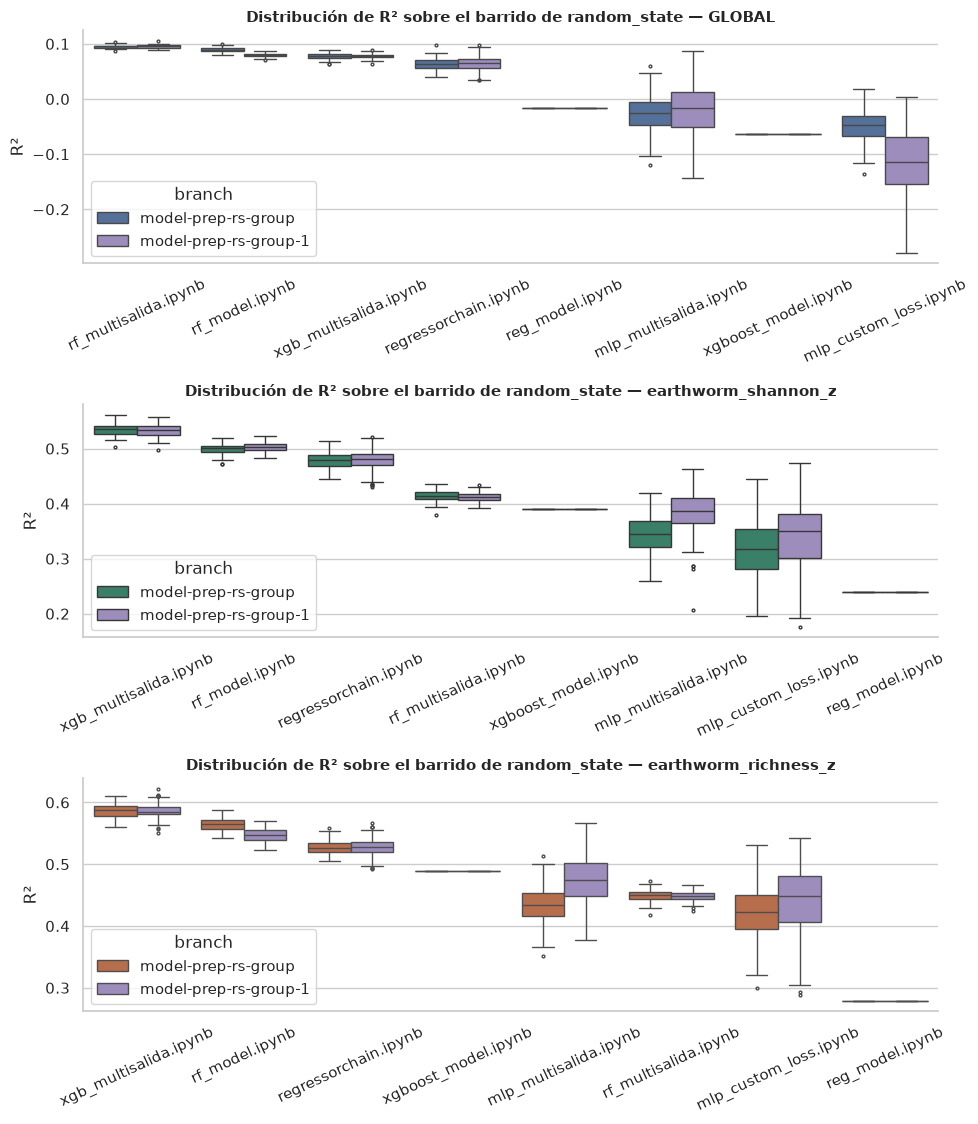

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

TARGET_COLORS = {"GLOBAL": "#4A6FA5", "earthworm_shannon_z": "#2E8B6B", "earthworm_richness_z": "#C9683A"}

targets_a_graficar = ["GLOBAL"] + TARGETS_PRIORITARIOS
fig, axes = plt.subplots(len(targets_a_graficar), 1, figsize=(10, 3.8 * len(targets_a_graficar)), squeeze=False)

for ax, target in zip(axes[:, 0], targets_a_graficar):
    sub = df_barrido[df_barrido["target"] == target]
    orden = sub.groupby("Notebook")["r2"].mean().sort_values(ascending=False).index
    sns.boxplot(data=sub, x="Notebook", y="r2", hue="branch", order=orden, ax=ax, fliersize=2,
                palette=[TARGET_COLORS.get(target, "#4A6FA5"), "#9B85C4"])
    ax.set_title(f"Distribución de R² sobre el barrido de random_state — {target}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("R²")
    ax.tick_params(axis="x", rotation=25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig("output/comparativas/barrido_boxplot.png", dpi=160, bbox_inches="tight")
plt.show()

In [32]:
print("=" * 100)
print("8.3.- RANKING MEDIO DE MODELOS A LO LARGO DE LAS SEMILLAS, POR RAMA")
print("=" * 100)

for branch in BRANCHES_BARRIDO:
    sub = df_barrido[(df_barrido["target"] == "GLOBAL") & (df_barrido["branch"] == branch)]
    pivot = sub.pivot(index="random_state", columns="Notebook", values="r2")
    ranking = pivot.rank(ascending=False, axis=1)
    resumen_rank = pd.DataFrame({
        "Ranking medio": ranking.mean().round(2),
        "Desviacion": ranking.std().round(2),
    }).sort_values("Ranking medio")
    print(f"\n--- {branch} ({len(pivot)} semillas) ---")
    print(resumen_rank.to_string())

8.3.- RANKING MEDIO DE MODELOS A LO LARGO DE LAS SEMILLAS, POR RAMA

--- model-prep-rs-group (101 semillas) ---
                       Ranking medio  Desviacion
Notebook                                        
rf_multisalida.ipynb            1.11        0.34
rf_model.ipynb                  1.96        0.37
xgb_multisalida.ipynb           3.04        0.37
regressorchain.ipynb            3.90        0.41
reg_model.ipynb                 5.48        0.63
mlp_multisalida.ipynb           6.02        0.99
mlp_custom_loss.ipynb           6.87        0.87
xgboost_model.ipynb             7.62        0.51

--- model-prep-rs-group-1 (491 semillas) ---
                       Ranking medio  Desviacion
Notebook                                        
rf_multisalida.ipynb            1.01        0.11
regressorchain.ipynb            1.52        1.12
rf_model.ipynb                  2.52        0.58
xgb_multisalida.ipynb           2.71        0.69
reg_model.ipynb                 5.53        0.52
mlp_multi